<a href="https://colab.research.google.com/github/rowanmacy/text-classifier/blob/main/Problem_2_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install optunahub and optuna
!pip install optunahub optuna cmaes scipy torch

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import os
import textwrap

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold,GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_score

from scipy.stats import uniform

import optuna
import optunahub

from sklearn.model_selection import GroupShuffleSplit

In [3]:
# Clone repo
!rm -rf /content/text-classifier  # clear any existing clone
!git clone "https://github.com/rowanmacy/text-classifier/"  # clone repo

Cloning into 'text-classifier'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 113 (delta 41), reused 29 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (113/113), 31.82 MiB | 8.44 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [4]:
# Check repo contents
!ls /content/text-classifier/starter_code/data_readinglevel/

x_test_BERT_embeddings.npz  x_train_BERT_embeddings.npz  y_train.csv
x_test.csv		    x_train.csv


## Read in data

In [5]:
# Read in training data
x_dev = np.array(np.load("/content/text-classifier/starter_code/data_readinglevel/x_train_BERT_embeddings.npz")['arr_0'])
x_df = pd.read_csv("/content/text-classifier/starter_code/data_readinglevel/x_train.csv")
y_dev = pd.read_csv("/content/text-classifier/starter_code/data_readinglevel/y_train.csv")
x_test  = np.array(np.load("/content/text-classifier/starter_code/data_readinglevel/x_test_BERT_embeddings.npz")['arr_0'])

In [6]:
# Convert coarse label into binary classification
y_dev['Class'] = (y_dev['Coarse Label'] == 'Key Stage 4-5').astype(int)
y_dev = y_dev['Class']

In [7]:
# Generate groups of unique combinations of author and title for grouping of CV splits later
author_title_combos = x_df[['author', 'title']].drop_duplicates()
author_title_combos['group'] = range(0, len(author_title_combos))

x_train_groupings = pd.merge(x_df, author_title_combos, on=['author', 'title'], how='left')

# Extract groups
groups = x_train_groupings['group'].values

## Pre-defined split for proxy test set (validation)

In [8]:
# Split using GroupShuffleSplit
split = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
split.get_n_splits()

# Capture training and validation indices
train_idx, val_idx = next(split.split(x_dev, y_dev, groups))

# Separate training and validation sets
X_train = x_dev[train_idx]
X_val = x_dev[val_idx]
y_train = y_dev.iloc[train_idx]
y_val = y_dev.iloc[val_idx]

# Capture groupings in training and validation sets
train_groups = groups[train_idx]
val_groups = groups[val_idx]

# Determine if there are any overlapping groups
shared_groups = list(set(train_groups) & set(val_groups))
print(shared_groups)

[]


In [8]:
# Set up objective function for Optuna
def objective(trial):

  # Suggest values for hyperparameters
  C = trial.suggest_float('C', 10e-4, 10e0, log=True)
  solver = trial.suggest_categorical('solver', ['saga', 'liblinear'])
  penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

  # Set up pipeline
  model = Pipeline([
      ('problem_2_model', LogisticRegression(max_iter=1500, random_state=101, penalty=penalty, C=C, solver=solver)),
  ])


  # Perform cross-validation and calculate AUROC
  group_k_fold = GroupKFold(n_splits=5)
  score = cross_val_score(model, X_train, y_train, groups=train_groups, cv=group_k_fold, scoring='roc_auc').mean()

  return score

In [9]:
# Load autosampler
module = optunahub.load_module(package="samplers/auto_sampler")

In [10]:
# Create and run study
study = optuna.create_study(direction='maximize', sampler=module.AutoSampler())
study.optimize(objective, n_trials=50)

[I 2026-03-04 20:01:34,615] A new study created in memory with name: no-name-3e63bd25-ad1c-4dcd-80f8-e6dfb021afa8
[I 2026-03-04 20:05:06,590] Trial 0 finished with value: 0.7412662320506709 and parameters: {'C': 1.0765690807120438, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 0 with value: 0.7412662320506709.
/root/.cache/optunahub/github.com/optuna/optunahub-registry/main/package/samplers/auto_sampler/_sampler.py:138: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  return TPESampler(
/root/.cache/optunahub/github.com/optuna/optunahub-registry/main/package/samplers/auto_sampler/_sampler.py:138: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  return TPESampler(
[I 2026-03-04 20:06:58,931] Trial 1 finished with value: 0.7294141538247354 and parameters: {'C': 1.3841320911553028, 'solver': 'saga', 'penalty': 'l2'}. Best is trial 0 with value: 0.741

In [11]:
# Extract parameters from best trial
trial = study.best_trial
hyperparameters = trial.params

for param, value in hyperparameters.items():
  print(f'{param}:', value)

print('\nBest score:', round(study.best_value,3))

C: 0.002815084819505393
solver: saga
penalty: l2

Best score: 0.771


In [10]:
# Train model with best performing hyperparameters on training set
model = Pipeline([
     ('problem_2_model', LogisticRegression(max_iter=500, random_state=101, penalty='l2', solver='saga', C=0.002815084819505393)),
  ])

model.fit(X_train, y_train)

Pipeline(steps=[('problem_2_model',
                 LogisticRegression(C=0.002815084819505393, max_iter=500,
                                    random_state=101, solver='saga'))])

In [11]:
# Evaluate performance on training and validation data
yhat_tr = model.predict_proba(X_train)[:,1]
yhat_val = model.predict_proba(X_val)[:,1]

# Calculate AUROC for training and validation predictions
roc_auc_tr = roc_auc_score(y_train, yhat_tr)
roc_auc_val = roc_auc_score(y_val, yhat_val)
print('Training score:', round(roc_auc_tr, 3))
print('Validation score:', round(roc_auc_val, 3))

Training score: 0.813
Validation score: 0.728


In [18]:
# Calculate difference between predictions and true labels
diff = np.abs(yhat_val - y_val)

# Calculate top three
top_three = np.argpartition(diff, 3)[:3]

# print('Top three most confidently correct values:')
for i in range(3):
  print(f'{i+1}) Entry {top_three[i]}:', round(yhat_val[top_three[i]],3), '(prediction),', round(np.asarray(y_val)[top_three[i]],3), '(actual)')

# Calculate worst three
bottom_three = np.argpartition(diff, -3)[-3:]

print('\nTop three most confidently incorrect values:')
for i in range(3):
  print(f'{i+1}) Entry {bottom_three[i]}:', round(yhat_val[bottom_three[i]],3), '(prediction),', round(np.asarray(y_val)[bottom_three[i]],3), '(actual)')

1) Entry 764: 0.963 (prediction), 1 (actual)
2) Entry 745: 0.959 (prediction), 1 (actual)
3) Entry 293: 0.94 (prediction), 1 (actual)

Top three most confidently incorrect values:
1) Entry 587: 0.887 (prediction), 0 (actual)
2) Entry 796: 0.894 (prediction), 0 (actual)
3) Entry 607: 0.921 (prediction), 0 (actual)


## Make predictions and plot ROC curve

In [19]:
# Print confusion matrices at 50% threshold
print('Training CF:\n', confusion_matrix(y_train, yhat_tr >= 0.5))
print('\nValidation CF:\n', confusion_matrix(y_val, yhat_val >= 0.5))

Training CF:
 [[1533  586]
 [ 644 1878]]

Validation CF:
 [[226 164]
 [146 380]]


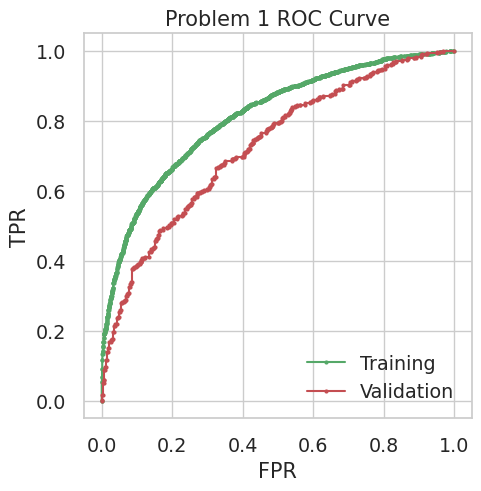

In [20]:
# Print ROC curves
tr_fpr, tr_tpr, tr_thresholds = roc_curve(y_train, yhat_tr)
val_fpr, val_tpr, val_thresholds = roc_curve(y_val, yhat_val)

plt.figure(figsize=(5,5))
plt.plot(tr_fpr, tr_tpr, 'g.-', label='Training')
plt.plot(val_fpr, val_tpr, 'r.-', label='Validation')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Problem 1 ROC Curve')
plt.legend(loc='lower right')

In [21]:
# Train model with best performing hyperparameters on development set
model = Pipeline([
     ('problem_1_model', LogisticRegression(max_iter=500, random_state=101, penalty=hyperparameters['penalty'], C=hyperparameters['C'])),
  ])

model.fit(x_dev, y_dev)

NameError: name 'hyperparameters' is not defined

## Create graphic for hyperparameter selection of 'min_df'

In [9]:
# Generate range of values for C and initialize AUROC score dictionaries
C_range = np.logspace(-4, 1, 20)
tr_AUROC = {}
val_AUROC = {}

In [ ]:
# Loop through values of min_df and calculate training and validation scores for 5 folds
gkf = GroupKFold(n_splits=5)
gkf.get_n_splits()
x_dev = np.array(x_dev)

for i, (train_idx, val_idx) in enumerate(gkf.split(x_dev, groups=groups)):
  X_train_fold = x_dev[train_idx]
  X_val_fold = x_dev[val_idx]
  y_train_fold = y_dev[train_idx]
  y_val_fold = y_dev[val_idx]

  tr_AUROC[i] = {}
  val_AUROC[i] = {}

  for C in C_range:
    problem_2_hyp_pipeline = Pipeline([
     ('problem_2_model', LogisticRegression(max_iter=1500, random_state=101, penalty='l2', solver='saga', C=C)),
     ])

    # Fit to training data
    problem_2_hyp_pipeline.fit(X_train_fold, y_train_fold)

    # Predict on training and validation sets
    yhat_tr = problem_2_hyp_pipeline.predict_proba(X_train_fold)[:,1]
    yhat_val = problem_2_hyp_pipeline.predict_proba(X_val_fold)[:,1]

    # Calculate and append AUROC scores
    tr_AUROC[i][C] = roc_auc_score(y_train_fold, yhat_tr)
    val_AUROC[i][C] = roc_auc_score(y_val_fold, yhat_val)

  print(val_AUROC[i][C])


In [ ]:
# Calculate mean
mean_tr_AUROC = {}
mean_val_AUROC = {}

for C in C_range:
  tr_sum = 0
  val_sum = 0
  for i in range(5):
    tr_sum += tr_AUROC[i][C]
    val_sum += val_AUROC[i][C]
  mean_tr_AUROC[C] = tr_sum / 5
  mean_val_AUROC[C] = val_sum /5


In [ ]:
# Plot training and validation AUROC vs. value of min_df
plt.figure(figsize=(8,6))
for i in range(5):
  plt.plot(C_range, tr_AUROC[i].values(), 'g--', alpha=0.3)
  plt.plot(C_range, val_AUROC[i].values(), 'r--', alpha=0.3)
plt.plot(C_range, mean_tr_AUROC.values(), 'g.-', label='Training')
plt.plot(C_range, mean_val_AUROC.values(), 'r.-', label='Validation')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('AUROC')
plt.title('AUROC vs. Inverse Regularization Strength')
plt.legend()
plt.xscale('log')

## Save results to file

In [ ]:
# Save parameters to text file
file = open('parameter_iterations.txt', "x")

with open('parameter_iterations.txt', "a") as f:
  for param, value in hyperparameters.items():
    f.write('\n' + str(param) + ': ' + str(value))
  f.write('\n\nTraining score: ' + str(round(roc_auc_tr, 3)))
  f.write('\nValidation Score: ' + str(round(roc_auc_val, 3)))
  f.write('\n\n')

In [ ]:
# Make predictions on test data
yhat_test = model.predict_proba(x_test)

In [ ]:
# Delete previous file
os.remove('yproba1_test.txt')

# # Save results to .txt file
file = open('yproba1_test.txt', "x")

with open('yproba1_test.txt', "w") as f:
    f.write('\n'.join(str(v) for v in yhat_test[:, 1]))